In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.figure import Figure

from __future__ import annotations

import argparse
from collections.abc import Iterable
from dataclasses import dataclass
from pathlib import Path

from scipy.stats import pearsonr, spearmanr
import pandas as pd

In [2]:
def load_h5(filepath: str | Path, filename: str) -> dict[str, np.ndarray]:
    """
    Load all datasets from an HDF5 file.

    Parameters
    ----------
    filepath
        Directory containing the HDF5 file.

    filename
        Name of the HDF5 file, including the .h5 extension.

    Returns
    -------
    dict[str, np.ndarray]
        Dictionary containing all HDF5 datasets.

        The dictionary keys are the full dataset paths inside the
        HDF5 file. The values are NumPy arrays.

    Raises
    ------
    FileNotFoundError
        If the requested HDF5 file does not exist.

    OSError
        If the file exists but cannot be opened as an HDF5 file.
    """
    full_path = Path(filepath) / filename

    if not full_path.is_file():
        raise FileNotFoundError(
            f"HDF5 file was not found: {full_path.resolve()}"
        )

    data: dict[str, np.ndarray] = {}

    with h5py.File(full_path, mode="r") as h5_file:

        def load_dataset(name: str, obj: h5py.Dataset | h5py.Group) -> None:
            if isinstance(obj, h5py.Dataset):
                data[name] = obj[...]

        h5_file.visititems(load_dataset)

    return data

In [3]:
parent_dir = Path("/blue/bala1s/krishnap.kalivel/TLFHydrodynamics/thinfilm-closure-ml/datasets/BasC/param_space")

# case_names = [
#     "Re010_Ca0_010_theta45",
#     "Re010_Ca0_010_theta45_v2",
#     "Re020_Ca0_010_theta45",
#     "Re050_Ca0_010_theta45",
#     "Re120_Ca0_010_theta45",
# ]

case_names = [
    "Re010_Ca0_010_theta45_v2",
    "Re050_Ca0_010_theta45",
    "Re120_Ca0_010_theta45",
]

filename = "thinfilm_closure_data.h5"

all_closure_data = {}

for case_name in case_names:
    case_dir = parent_dir / case_name
    file_path = case_dir / filename

    if file_path.exists():
        all_closure_data[case_name] = load_h5(case_dir, filename)
        print(f"Loaded: {case_name}")
    else:
        print(f"Missing: {file_path}")

Loaded: Re010_Ca0_010_theta45_v2
Loaded: Re050_Ca0_010_theta45
Loaded: Re120_Ca0_010_theta45


In [4]:
for case_name, closure_data in all_closure_data.items():
    print(f"\n{case_name}")
    print("-" * len(case_name))

    for key, value in closure_data.items():
        print(f"  {key:<35} shape={value.shape}, dtype={value.dtype}")


Re010_Ca0_010_theta45_v2
------------------------
  dt                                  shape=(199,), dtype=float64
  h                                   shape=(16384, 199), dtype=float64
  h_m                                 shape=(16384, 199), dtype=float64
  h_x                                 shape=(16384, 199), dtype=float64
  h_xx                                shape=(16384, 199), dtype=float64
  parameters/Ca                       shape=(), dtype=float64
  parameters/Re                       shape=(), dtype=float64
  parameters/angle                    shape=(), dtype=float64
  parameters/h0                       shape=(), dtype=float64
  parameters/mu_ratio                 shape=(), dtype=float64
  parameters/rho_ratio                shape=(), dtype=float64
  parameters/t0                       shape=(), dtype=float64
  parameters/u0                       shape=(), dtype=float64
  q                                   shape=(16384, 199), dtype=float64
  q_m                      

In [5]:
def first_derivative_x(
    x: np.ndarray,
    field: np.ndarray,
) -> np.ndarray:
    """
    Compute the first derivative with respect to x for a field
    stored as (nx, nt).

    Fourth-order central differences are used in the interior.
    Fourth-order one-sided differences are used near the boundaries.

    Parameters
    ----------
    x : ndarray, shape (nx,)
        Uniformly spaced x coordinates.

    field : ndarray, shape (nx, nt)
        Field values. The first axis must correspond to x.

        Examples:
            h
            q
            tau_wall
            shape_factor

    Returns
    -------
    dfield_dx : ndarray, shape (nx, nt)
        Fourth-order approximation to df/dx at every time.
    """

    x = np.asarray(x, dtype=float)
    field = np.asarray(field, dtype=float)

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    if x.ndim != 1:
        raise ValueError(
            "x must be a one-dimensional array."
        )

    if field.ndim != 2:
        raise ValueError(
            "field must have shape (nx, nt)."
        )

    if field.shape[0] != x.size:
        raise ValueError(
            "The first dimension of field must equal len(x). "
            f"Received field.shape={field.shape}, "
            f"len(x)={x.size}."
        )

    if x.size < 5:
        raise ValueError(
            "At least five x points are required for "
            "fourth-order differentiation."
        )

    dx_values = np.diff(x)
    dx = dx_values[0]

    if dx <= 0.0:
        raise ValueError(
            "x coordinates must increase monotonically."
        )

    if not np.allclose(dx_values, dx):
        raise ValueError(
            "The x grid must be uniformly spaced."
        )

    dfield_dx = np.empty_like(field, dtype=float)

    # --------------------------------------------------------
    # Interior
    # Fourth-order central difference
    # --------------------------------------------------------

    dfield_dx[2:-2, :] = (
        field[:-4, :]
        - 8.0 * field[1:-3, :]
        + 8.0 * field[3:-1, :]
        - field[4:, :]
    ) / (12.0 * dx)

    # --------------------------------------------------------
    # Left boundary
    # --------------------------------------------------------

    dfield_dx[0, :] = (
        -25.0 * field[0, :]
        + 48.0 * field[1, :]
        - 36.0 * field[2, :]
        + 16.0 * field[3, :]
        - 3.0 * field[4, :]
    ) / (12.0 * dx)

    dfield_dx[1, :] = (
        -3.0 * field[0, :]
        - 10.0 * field[1, :]
        + 18.0 * field[2, :]
        - 6.0 * field[3, :]
        + field[4, :]
    ) / (12.0 * dx)

    # --------------------------------------------------------
    # Right boundary
    # --------------------------------------------------------

    dfield_dx[-2, :] = (
        -field[-5, :]
        + 6.0 * field[-4, :]
        - 18.0 * field[-3, :]
        + 10.0 * field[-2, :]
        + 3.0 * field[-1, :]
    ) / (12.0 * dx)

    dfield_dx[-1, :] = (
        3.0 * field[-5, :]
        - 16.0 * field[-4, :]
        + 36.0 * field[-3, :]
        - 48.0 * field[-2, :]
        + 25.0 * field[-1, :]
    ) / (12.0 * dx)

    return dfield_dx

In [6]:
def second_derivative_x(
    x: np.ndarray,
    field: np.ndarray,
) -> np.ndarray:
    """
    Compute the second derivative with respect to x for a field
    stored as (nx, nt).

    Fourth-order central differences are used in the interior.
    Fourth-order one-sided differences are used near boundaries.

    Parameters
    ----------
    x : ndarray, shape (nx,)
        Uniformly spaced x coordinates.

    field : ndarray, shape (nx, nt)
        Field values. The first axis corresponds to x.

    Returns
    -------
    d2field_dx2 : ndarray, shape (nx, nt)
        Fourth-order approximation to d²f/dx².
    """

    x = np.asarray(x, dtype=float)
    field = np.asarray(field, dtype=float)

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    if x.ndim != 1:
        raise ValueError(
            "x must be one-dimensional."
        )

    if field.ndim != 2:
        raise ValueError(
            "field must have shape (nx, nt)."
        )

    if field.shape[0] != x.size:
        raise ValueError(
            "The first dimension of field must equal len(x). "
            f"Received field.shape={field.shape}, "
            f"len(x)={x.size}."
        )

    if x.size < 6:
        raise ValueError(
            "At least six x points are required."
        )

    dx_values = np.diff(x)
    dx = dx_values[0]

    if dx <= 0.0:
        raise ValueError(
            "x coordinates must increase monotonically."
        )

    if not np.allclose(dx_values, dx):
        raise ValueError(
            "The x grid must be uniformly spaced."
        )

    d2field_dx2 = np.empty_like(
        field,
        dtype=float,
    )

    # --------------------------------------------------------
    # Interior
    # --------------------------------------------------------

    d2field_dx2[2:-2, :] = (
        -field[4:, :]
        + 16.0 * field[3:-1, :]
        - 30.0 * field[2:-2, :]
        + 16.0 * field[1:-3, :]
        - field[:-4, :]
    ) / (12.0 * dx**2)

    # --------------------------------------------------------
    # Left boundary
    # --------------------------------------------------------

    d2field_dx2[0, :] = (
        45.0 * field[0, :]
        - 154.0 * field[1, :]
        + 214.0 * field[2, :]
        - 156.0 * field[3, :]
        + 61.0 * field[4, :]
        - 10.0 * field[5, :]
    ) / (12.0 * dx**2)

    d2field_dx2[1, :] = (
        10.0 * field[0, :]
        - 15.0 * field[1, :]
        - 4.0 * field[2, :]
        + 14.0 * field[3, :]
        - 6.0 * field[4, :]
        + field[5, :]
    ) / (12.0 * dx**2)

    # --------------------------------------------------------
    # Right boundary
    # --------------------------------------------------------

    d2field_dx2[-2, :] = (
        field[-6, :]
        - 6.0 * field[-5, :]
        + 14.0 * field[-4, :]
        - 4.0 * field[-3, :]
        - 15.0 * field[-2, :]
        + 10.0 * field[-1, :]
    ) / (12.0 * dx**2)

    d2field_dx2[-1, :] = (
        -10.0 * field[-6, :]
        + 61.0 * field[-5, :]
        - 156.0 * field[-4, :]
        + 214.0 * field[-3, :]
        - 154.0 * field[-2, :]
        + 45.0 * field[-1, :]
    ) / (12.0 * dx**2)

    return d2field_dx2

In [7]:
def first_derivative_t(
    field: np.ndarray,
    field_minus: np.ndarray,
    time: np.ndarray,
    time_minus: np.ndarray,
) -> np.ndarray:
    """
    Compute first-order backward time derivatives for a field
    stored as (nx, nt).

    Each current snapshot has a corresponding previous snapshot:

        df/dt[:, j] =
            (field[:, j] - field_minus[:, j])
            / (time[j] - time_minus[j])

    Parameters
    ----------
    field : ndarray, shape (nx, nt)
        Quantity at the current snapshot times.

    field_minus : ndarray, shape (nx, nt)
        Same quantity at the corresponding previous times.

    time : ndarray, shape (nt,)
        Current snapshot times.

    time_minus : ndarray, shape (nt,)
        Previous snapshot times.

    Returns
    -------
    dfield_dt : ndarray, shape (nx, nt)
        First-order approximation to df/dt.
    """

    field = np.asarray(field, dtype=float)
    field_minus = np.asarray(field_minus, dtype=float)

    time = np.asarray(time, dtype=float)
    time_minus = np.asarray(time_minus, dtype=float)

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    if field.ndim != 2:
        raise ValueError(
            "field must have shape (nx, nt)."
        )

    if field_minus.ndim != 2:
        raise ValueError(
            "field_minus must have shape (nx, nt)."
        )

    if field.shape != field_minus.shape:
        raise ValueError(
            "field and field_minus must have identical shapes. "
            f"Received {field.shape} and {field_minus.shape}."
        )

    if time.ndim != 1 or time_minus.ndim != 1:
        raise ValueError(
            "time and time_minus must be one-dimensional."
        )

    if time.shape != time_minus.shape:
        raise ValueError(
            "time and time_minus must have identical shapes."
        )

    if field.shape[1] != time.size:
        raise ValueError(
            "The second dimension of field must match "
            "the number of time values. "
            f"Received field.shape={field.shape}, "
            f"time.size={time.size}."
        )

    dt = time - time_minus

    if np.any(dt <= 0.0):
        bad_indices = np.where(dt <= 0.0)[0]

        raise ValueError(
            "All time values must be greater than their "
            "corresponding time_minus values. "
            f"Bad indices: {bad_indices[:10]}"
        )

    # dt has shape (nt,)
    #
    # field has shape (nx, nt)
    #
    # NumPy broadcasts dt across the x dimension.

    dfield_dt = (
        field - field_minus
    ) / dt[np.newaxis, :]

    return dfield_dt

Interface plots for all cases

In [8]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [9]:
for case_name, data in all_closure_data.items():
    t_case = data["t"]

    print(f"{case_name:<30} t_max = {np.max(t_case):10.4f}    snapshots = {len(t_case)}")

Re010_Ca0_010_theta45_v2       t_max =  1990.0000    snapshots = 199
Re050_Ca0_010_theta45          t_max =  1060.0000    snapshots = 106
Re120_Ca0_010_theta45          t_max =   300.0000    snapshots = 30


In [10]:
h_mean = 1.0
h_tolerance = 0.1

analysis_masks = {}

for case_name, data in all_closure_data.items():

    x_case = data["x"]
    h_case = data["h"]
    t_case = data["t"]

    nx, nt = h_case.shape

    analysis_mask = np.zeros((nx, nt), dtype=bool)

    for j in range(nt):

        h_snapshot = h_case[:, j]

        flat = np.abs(h_snapshot - h_mean) <= h_tolerance
        disturbed = ~flat

        disturbed_indices = np.where(disturbed)[0]

        if disturbed_indices.size == 0:
            continue

        last_disturbed_index = disturbed_indices[-1]

        analysis_mask[:last_disturbed_index + 1, j] = True

    analysis_masks[case_name] = analysis_mask

    retained = np.sum(analysis_mask)
    total = analysis_mask.size

    print(f"{case_name:<30} retained = {retained / total * 100:.2f}%")

Re010_Ca0_010_theta45_v2       retained = 93.83%
Re050_Ca0_010_theta45          retained = 84.83%
Re120_Ca0_010_theta45          retained = 39.30%


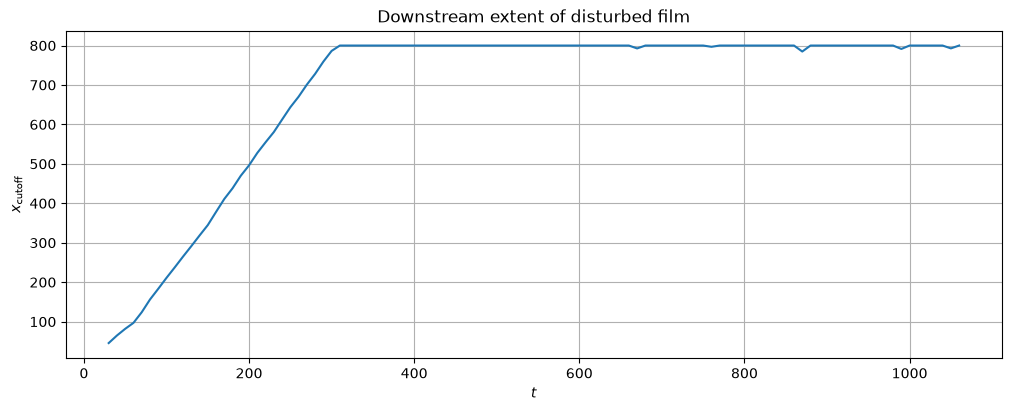

In [11]:
case_name = "Re050_Ca0_010_theta45"

data = all_closure_data[case_name]

x_case = data["x"]
h_case = data["h"]
t_case = data["t"]

mask = analysis_masks[case_name]

x_cutoff = np.full(len(t_case), np.nan)

for j in range(len(t_case)):

    retained_indices = np.where(mask[:, j])[0]

    if retained_indices.size > 0:
        x_cutoff[j] = x_case[retained_indices[-1]]

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

ax.plot(t_case, x_cutoff)

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$x_{\mathrm{cutoff}}$")
ax.set_title("Downstream extent of disturbed film")
ax.grid(True)

plt.show()

In [12]:
train_fraction = 0.70
val_fraction = 0.15

temporal_splits = {}

for case_name in case_names:

    data = all_closure_data[case_name]

    t = data["t"]
    nt = len(t)

    train_end = int(train_fraction * nt)
    val_end = int((train_fraction + val_fraction) * nt)

    train_indices = np.arange(0, train_end)
    val_indices = np.arange(train_end, val_end)
    test_indices = np.arange(val_end, nt)

    temporal_splits[case_name] = {
        "train": train_indices,
        "val": val_indices,
        "test": test_indices,
    }

    print(f"\n{case_name}")
    print(f"Total snapshots: {nt}")
    print(f"Train: {len(train_indices):3d} snapshots, t = {t[train_indices[0]]:.3f} to {t[train_indices[-1]]:.3f}")
    print(f"Val:   {len(val_indices):3d} snapshots, t = {t[val_indices[0]]:.3f} to {t[val_indices[-1]]:.3f}")
    print(f"Test:  {len(test_indices):3d} snapshots, t = {t[test_indices[0]]:.3f} to {t[test_indices[-1]]:.3f}")


Re010_Ca0_010_theta45_v2
Total snapshots: 199
Train: 139 snapshots, t = 10.000 to 1390.000
Val:    30 snapshots, t = 1400.000 to 1690.000
Test:   30 snapshots, t = 1700.000 to 1990.000

Re050_Ca0_010_theta45
Total snapshots: 106
Train:  74 snapshots, t = 10.000 to 740.000
Val:    16 snapshots, t = 750.000 to 900.000
Test:   16 snapshots, t = 910.000 to 1060.000

Re120_Ca0_010_theta45
Total snapshots: 30
Train:  21 snapshots, t = 10.000 to 210.000
Val:     4 snapshots, t = 220.000 to 250.000
Test:    5 snapshots, t = 260.000 to 300.000


In [13]:
case_name = "Re050_Ca0_010_theta45"

data = all_closure_data[case_name]

train_idx = temporal_splits[case_name]["train"]

h_train = data["h"][:, train_idx]
q_train = data["q"][:, train_idx]
h_x_train = data["h_x"][:, train_idx]
q_x_train = data["q_x"][:, train_idx]

mask_train = analysis_masks[case_name][:, train_idx]

tau_w_train = data["tau_wall"][:, train_idx]

tau_w_correction_train = tau_w_train - 3.0 * q_train / h_train**2

In [14]:
for case_name in case_names:

    print(f"\n{case_name}")

    for split_name in ["train", "val", "test"]:

        indices = temporal_splits[case_name][split_name]
        mask = analysis_masks[case_name][:, indices]

        n_points = np.sum(mask)

        print(f"  {split_name:<5}: {n_points:10d} points")


Re010_Ca0_010_theta45_v2
  train:    2076925 points
  val  :     491123 points
  test :     491062 points

Re050_Ca0_010_theta45
  train:     949669 points
  val  :     261768 points
  test :     261819 points

Re120_Ca0_010_theta45
  train:     175387 points
  val  :      83471 points
  test :     127478 points


In [15]:
feature_names = ["Re", "h", "q", "h_x", "q_x"]

ml_data = {}

for case_name in case_names:

    data = all_closure_data[case_name]

    h = data["h"]
    q = data["q"]
    h_x = data["h_x"]
    q_x = data["q_x"]
    tau_w = data["tau_wall"]

    Re_case = float(data["parameters/Re"])

    nx, nt = h.shape

    tau_w_correction = tau_w - 3.0 * q / h**2

    ml_data[case_name] = {}

    for split_name in ["train", "val", "test"]:

        time_indices = temporal_splits[case_name][split_name]

        h_split = h[:, time_indices]
        q_split = q[:, time_indices]
        h_x_split = h_x[:, time_indices]
        q_x_split = q_x[:, time_indices]
        y_split = tau_w_correction[:, time_indices]

        mask_split = analysis_masks[case_name][:, time_indices]

        n_points = np.sum(mask_split)

        X_split = np.column_stack([
            np.full(n_points, Re_case),
            h_split[mask_split],
            q_split[mask_split],
            h_x_split[mask_split],
            q_x_split[mask_split],
        ])

        Y_split = y_split[mask_split]

        ix_grid = np.broadcast_to(np.arange(nx)[:, None], mask_split.shape)
        it_grid = np.broadcast_to(time_indices[None, :], mask_split.shape)

        ix_split = ix_grid[mask_split]
        it_split = it_grid[mask_split]

        valid = np.all(np.isfinite(X_split), axis=1) & np.isfinite(Y_split)

        X_split = X_split[valid]
        Y_split = Y_split[valid]
        ix_split = ix_split[valid]
        it_split = it_split[valid]

        ml_data[case_name][split_name] = {
            "X": X_split,
            "Y": Y_split,
            "ix": ix_split,
            "it": it_split,
        }

        print(f"{case_name:<30} {split_name:<5} X = {X_split.shape}   Y = {Y_split.shape}")

Re010_Ca0_010_theta45_v2       train X = (2076925, 5)   Y = (2076925,)
Re010_Ca0_010_theta45_v2       val   X = (491123, 5)   Y = (491123,)
Re010_Ca0_010_theta45_v2       test  X = (491062, 5)   Y = (491062,)
Re050_Ca0_010_theta45          train X = (949669, 5)   Y = (949669,)
Re050_Ca0_010_theta45          val   X = (261768, 5)   Y = (261768,)
Re050_Ca0_010_theta45          test  X = (261819, 5)   Y = (261819,)
Re120_Ca0_010_theta45          train X = (175387, 5)   Y = (175387,)
Re120_Ca0_010_theta45          val   X = (83471, 5)   Y = (83471,)
Re120_Ca0_010_theta45          test  X = (127478, 5)   Y = (127478,)


In [16]:
case_name = "Re050_Ca0_010_theta45"

print(ml_data[case_name]["train"]["X"].shape)
print(ml_data[case_name]["train"]["Y"].shape)

print(ml_data[case_name]["train"]["ix"][:10])
print(ml_data[case_name]["train"]["it"][:10])

print(feature_names)
print(ml_data[case_name]["train"]["X"][:5])
print(ml_data[case_name]["train"]["Y"][:5])

(949669, 5)
(949669,)
[0 0 0 0 0 0 0 0 0 0]
[ 2  3  4  5  6  7  8  9 10 11]
['Re', 'h', 'q', 'h_x', 'q_x']
[[ 5.00000000e+01  1.00068200e+00  1.02861269e+00 -4.73241505e-03
  -2.94458520e-02]
 [ 5.00000000e+01  1.00038288e+00  1.00880296e+00 -1.82094144e-03
  -2.04018868e-02]
 [ 5.00000000e+01  1.00001955e+00  9.32853267e-01 -2.54010295e-03
  -1.97421486e-02]
 [ 5.00000000e+01  1.00121405e+00  1.03116645e+00 -1.36316662e-04
  -9.58941979e-03]
 [ 5.00000000e+01  9.99986897e-01  1.02421989e+00 -2.72798993e-03
  -2.35716927e-02]]
[0.05655326 0.05379358 0.04836094 0.06062336 0.05190097]


In [17]:
from sklearn.preprocessing import StandardScaler

samples_per_case = 150000
rng = np.random.default_rng(42)

X_scaler_samples = []
Y_scaler_samples = []

for case_name in case_names:

    X_case = ml_data[case_name]["train"]["X"]
    Y_case = ml_data[case_name]["train"]["Y"]

    n_samples = len(Y_case)

    if n_samples > samples_per_case:
        idx = rng.choice(n_samples, samples_per_case, replace=False)
    else:
        idx = np.arange(n_samples)

    X_scaler_samples.append(X_case[idx])
    Y_scaler_samples.append(Y_case[idx])

X_scaler_train = np.vstack(X_scaler_samples)
Y_scaler_train = np.concatenate(Y_scaler_samples)

print("Balanced X used for scaling:", X_scaler_train.shape)
print("Balanced Y used for scaling:", Y_scaler_train.shape)

Balanced X used for scaling: (450000, 5)
Balanced Y used for scaling: (450000,)


In [18]:
X_scaler = StandardScaler()
Y_scaler = StandardScaler()

X_scaler.fit(X_scaler_train)
Y_scaler.fit(Y_scaler_train.reshape(-1, 1))

StandardScaler()

In [19]:
print("Input scaling statistics:")

for name, mean, std in zip(feature_names, X_scaler.mean_, X_scaler.scale_):
    print(f"{name:<6} mean = {mean: .6f}   std = {std: .6f}")

print()
print(f"Target mean = {Y_scaler.mean_[0]: .6f}")
print(f"Target std  = {Y_scaler.scale_[0]: .6f}")

Input scaling statistics:
Re     mean =  60.000000   std =  45.460606
h      mean =  0.963852   std =  0.302010
q      mean =  1.008271   std =  0.754373
h_x    mean = -0.000149   std =  0.102251
q_x    mean = -0.000150   std =  0.212068

Target mean =  0.071718
Target std  =  0.867270


In [20]:
for case_name in case_names:

    for split_name in ["train", "val", "test"]:

        X = ml_data[case_name][split_name]["X"]
        Y = ml_data[case_name][split_name]["Y"]

        X_scaled = X_scaler.transform(X)
        Y_scaled = Y_scaler.transform(Y.reshape(-1, 1)).ravel()

        ml_data[case_name][split_name]["X_scaled"] = X_scaled
        ml_data[case_name][split_name]["Y_scaled"] = Y_scaled

In [21]:
## Checking if scaling worked

X_check = X_scaler.transform(X_scaler_train)
Y_check = Y_scaler.transform(Y_scaler_train.reshape(-1, 1)).ravel()

print("Balanced training sample")
print("X mean:", np.mean(X_check, axis=0))
print("X std: ", np.std(X_check, axis=0))
print("Y mean:", np.mean(Y_check))
print("Y std: ", np.std(Y_check))

Balanced training sample
X mean: [-7.70759549e-13  4.80235417e-14  2.83756534e-14  2.87128346e-18
 -3.05905918e-17]
X std:  [1. 1. 1. 1. 1.]
Y mean: 4.0421986745463475e-18
Y std:  0.9999999999999999


In [22]:
for case_name in case_names:

    X = ml_data[case_name]["train"]["X_scaled"]
    Y = ml_data[case_name]["train"]["Y_scaled"]

    print(f"\n{case_name}")
    print("X mean:", np.mean(X, axis=0))
    print("X std: ", np.std(X, axis=0))
    print(f"Y mean: {np.mean(Y):.4f}")
    print(f"Y std:  {np.std(Y):.4f}")


Re010_Ca0_010_theta45_v2
X mean: [-1.09985336e+00 -9.41913507e-02 -1.85799361e-02  6.07881869e-04
  9.58101542e-04]
X std:  [1.43609569e-11 9.62949494e-01 1.21922819e+00 6.31554568e-01
 9.27808092e-01]
Y mean: -0.0141
Y std:  0.4425

Re050_Ca0_010_theta45
X mean: [-2.19970673e-01 -5.18355464e-02 -1.18235375e-02 -4.18144650e-05
  6.27101275e-04]
X std:  [3.01816905e-12 1.22094570e+00 1.11312206e+00 1.14761318e+00
 1.16807367e+00]
Y mean: 0.0032
Y std:  1.2517

Re120_Ca0_010_theta45
X mean: [ 1.31982404e+00  1.40620606e-01  2.39903556e-02 -1.21218429e-03
 -1.34022144e-03]
X std:  [3.79696274e-14 7.37094087e-01 5.01789476e-01 1.13221108e+00
 8.80787854e-01]
Y mean: 0.0105
Y std:  1.1147


In [23]:
import torch
from torch.utils.data import TensorDataset, DataLoader

samples_per_case = 150000
rng = np.random.default_rng(42)

X_train_list = []
Y_train_list = []

for case_name in case_names:

    X_case = ml_data[case_name]["train"]["X_scaled"]
    Y_case = ml_data[case_name]["train"]["Y_scaled"]

    n_samples = len(Y_case)

    if n_samples > samples_per_case:
        idx = rng.choice(n_samples, samples_per_case, replace=False)
    else:
        idx = np.arange(n_samples)

    X_train_list.append(X_case[idx])
    Y_train_list.append(Y_case[idx])

X_train = np.vstack(X_train_list).astype(np.float32)
Y_train = np.concatenate(Y_train_list).astype(np.float32)

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

X_train: (450000, 5)
Y_train: (450000,)


In [24]:
X_train_tensor = torch.from_numpy(X_train)
Y_train_tensor = torch.from_numpy(Y_train).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)

In [25]:
batch_size = 8192

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)

In [26]:
X_val_list = []
Y_val_list = []

for case_name in case_names:

    X_case = ml_data[case_name]["val"]["X_scaled"]
    Y_case = ml_data[case_name]["val"]["Y_scaled"]

    X_val_list.append(X_case)
    Y_val_list.append(Y_case)

X_val = np.vstack(X_val_list).astype(np.float32)
Y_val = np.concatenate(Y_val_list).astype(np.float32)

X_val_tensor = torch.from_numpy(X_val)
Y_val_tensor = torch.from_numpy(Y_val).unsqueeze(1)

val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [27]:
X_test_list = []
Y_test_list = []

for case_name in case_names:

    X_case = ml_data[case_name]["test"]["X_scaled"]
    Y_case = ml_data[case_name]["test"]["Y_scaled"]

    X_test_list.append(X_case)
    Y_test_list.append(Y_case)

X_test = np.vstack(X_test_list).astype(np.float32)
Y_test = np.concatenate(Y_test_list).astype(np.float32)

X_test_tensor = torch.from_numpy(X_test)
Y_test_tensor = torch.from_numpy(Y_test).unsqueeze(1)

test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [28]:
print("Training samples:  ", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:      ", len(test_dataset))

xb, yb = next(iter(train_loader))

print("Batch X shape:", xb.shape)
print("Batch Y shape:", yb.shape)
print("X dtype:", xb.dtype)
print("Y dtype:", yb.dtype)

Training samples:   450000
Validation samples: 836362
Test samples:       880359
Batch X shape: torch.Size([8192, 5])
Batch Y shape: torch.Size([8192, 1])
X dtype: torch.float32
Y dtype: torch.float32


Baseline model

In [29]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

class MLP(nn.Module):

    def __init__(self, input_dim=5, hidden_dim=64, output_dim=1):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.network(x)

model = MLP(
    input_dim=len(feature_names),
    hidden_dim=64,
    output_dim=1,
).to(device)

print(model)

Device: cpu
MLP(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [30]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1.0e-3,
)

In [31]:
n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Trainable parameters: {n_parameters:,}")

Trainable parameters: 8,769


In [43]:
model_dir = Path("saved_models")

model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "MLP_Stage1_v01.pt"

best_val_loss = np.inf

In [44]:
n_epochs = 100

train_losses = []
val_losses = []

best_train_loss = np.inf

for epoch in range(n_epochs):

    model.train()

    train_loss_sum = 0.0
    train_count = 0

    for X_batch, Y_batch in train_loader:

        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        optimizer.zero_grad()

        Y_pred = model(X_batch)

        loss = criterion(Y_pred, Y_batch)

        loss.backward()

        optimizer.step()

        batch_size_current = X_batch.size(0)

        train_loss_sum += loss.item() * batch_size_current
        train_count += batch_size_current

    train_loss = train_loss_sum / train_count


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    model.eval()

    val_loss_sum = 0.0
    val_count = 0

    with torch.no_grad():

        for X_batch, Y_batch in val_loader:

            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            Y_pred = model(X_batch)

            loss = criterion(Y_pred, Y_batch)

            batch_size_current = X_batch.size(0)

            val_loss_sum += loss.item() * batch_size_current
            val_count += batch_size_current

    val_loss = val_loss_sum / val_count


    # --------------------------------------------------------
    # Store loss history
    # --------------------------------------------------------

    train_losses.append(train_loss)
    val_losses.append(val_loss)


    # --------------------------------------------------------
    # Save model if training loss improves
    # --------------------------------------------------------

    if train_loss < best_train_loss:

        best_train_loss = train_loss

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "feature_names": feature_names,
            "X_scaler_mean": X_scaler.mean_,
            "X_scaler_scale": X_scaler.scale_,
            "Y_scaler_mean": Y_scaler.mean_,
            "Y_scaler_scale": Y_scaler.scale_,
        }, model_path)

        print(
            f"Epoch {epoch + 1:3d}/{n_epochs}   "
            f"Train = {train_loss:.6e}   "
            f"Val = {val_loss:.6e}   "
            f"Saved"
        )

    else:

        print(
            f"Epoch {epoch + 1:3d}/{n_epochs}   "
            f"Train = {train_loss:.6e}   "
            f"Val = {val_loss:.6e}"
        )


# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print()
print(f"Best training loss = {best_train_loss:.6e}")
print(f"Saved model path   = {model_path.resolve()}")

Epoch   1/100   Train = 3.701502e-02   Val = 4.070387e-02   Saved
Epoch   2/100   Train = 3.705872e-02   Val = 4.019274e-02
Epoch   3/100   Train = 3.707410e-02   Val = 4.104573e-02
Epoch   4/100   Train = 3.706843e-02   Val = 4.077665e-02
Epoch   5/100   Train = 3.662910e-02   Val = 4.102558e-02   Saved
Epoch   6/100   Train = 3.679358e-02   Val = 4.103444e-02
Epoch   7/100   Train = 3.664397e-02   Val = 4.125807e-02
Epoch   8/100   Train = 3.674680e-02   Val = 4.030923e-02
Epoch   9/100   Train = 3.643850e-02   Val = 4.126118e-02   Saved
Epoch  10/100   Train = 3.656903e-02   Val = 4.125437e-02
Epoch  11/100   Train = 3.671673e-02   Val = 4.130735e-02
Epoch  12/100   Train = 3.658586e-02   Val = 4.173439e-02
Epoch  13/100   Train = 3.715854e-02   Val = 3.999260e-02
Epoch  14/100   Train = 3.629005e-02   Val = 4.004676e-02   Saved
Epoch  15/100   Train = 3.614089e-02   Val = 4.073633e-02   Saved
Epoch  16/100   Train = 3.626662e-02   Val = 4.051524e-02
Epoch  17/100   Train = 3.602677

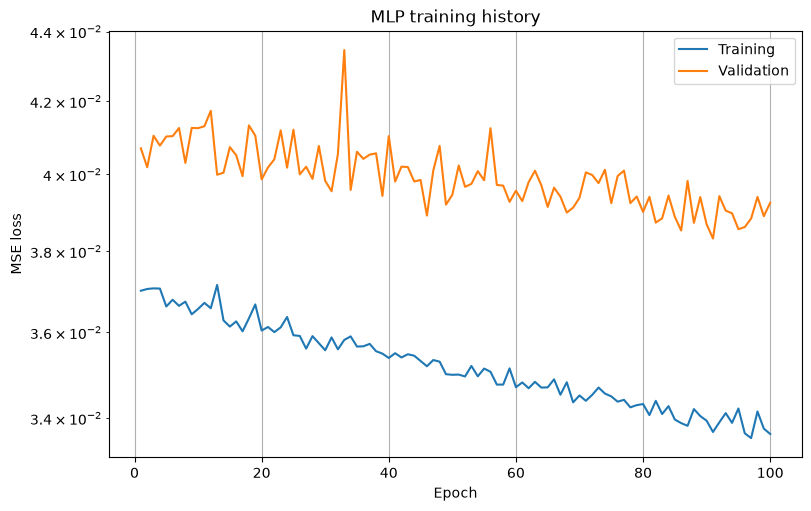

In [45]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

epochs = np.arange(1, n_epochs + 1)

ax.plot(epochs, train_losses, label="Training")
ax.plot(epochs, val_losses, label="Validation")

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("MLP training history")
ax.set_yscale("log")
ax.grid(True)
ax.legend()

plt.show()

In [46]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model.eval()

Y_test_pred_scaled = []

with torch.no_grad():

    for X_batch, Y_batch in test_loader:

        X_batch = X_batch.to(device)

        Y_pred = model(X_batch)

        Y_test_pred_scaled.append(Y_pred.cpu().numpy())

Y_test_pred_scaled = np.vstack(Y_test_pred_scaled).ravel()

Y_test_true = Y_scaler.inverse_transform(Y_test.reshape(-1, 1)).ravel()
Y_test_pred = Y_scaler.inverse_transform(Y_test_pred_scaled.reshape(-1, 1)).ravel()

mse = mean_squared_error(Y_test_true, Y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test_true, Y_test_pred)
r2 = r2_score(Y_test_true, Y_test_pred)

print(f"MSE  = {mse:.6e}")
print(f"RMSE = {rmse:.6e}")
print(f"MAE  = {mae:.6e}")
print(f"R2   = {r2:.6f}")

MSE  = 4.823986e-02
RMSE = 2.196357e-01
MAE  = 8.899986e-02
R2   = 0.931319


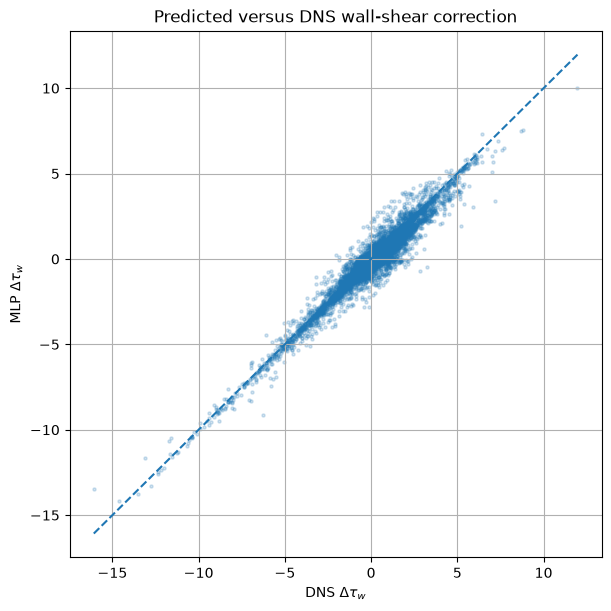

In [47]:
sample_size = 50000
rng = np.random.default_rng(42)

if len(Y_test_true) > sample_size:
    idx = rng.choice(len(Y_test_true), sample_size, replace=False)
else:
    idx = np.arange(len(Y_test_true))

fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

ax.scatter(Y_test_true[idx], Y_test_pred[idx], s=5, alpha=0.2)

ymin = min(Y_test_true[idx].min(), Y_test_pred[idx].min())
ymax = max(Y_test_true[idx].max(), Y_test_pred[idx].max())

ax.plot([ymin, ymax], [ymin, ymax], "--")

ax.set_xlabel(r"DNS $\Delta\tau_w$")
ax.set_ylabel(r"MLP $\Delta\tau_w$")
ax.set_title("Predicted versus DNS wall-shear correction")
ax.grid(True)

plt.show()

In [48]:
for case_name in case_names:

    X_case = ml_data[case_name]["test"]["X_scaled"].astype(np.float32)
    Y_case = ml_data[case_name]["test"]["Y"]

    X_case_tensor = torch.from_numpy(X_case).to(device)

    model.eval()

    with torch.no_grad():
        Y_pred_scaled = model(X_case_tensor).cpu().numpy().ravel()

    Y_pred = Y_scaler.inverse_transform(Y_pred_scaled.reshape(-1, 1)).ravel()

    mse = mean_squared_error(Y_case, Y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(Y_case, Y_pred)
    r2 = r2_score(Y_case, Y_pred)
    nrmse = rmse / np.std(Y_case)

    print(case_name)
    print(f"  MSE  = {mse:.6e}")
    print(f"  RMSE = {rmse:.6e}")
    print(f"  MAE  = {mae:.6e}")
    print(f"  R2   = {r2:.6f}")
    print(f"  NRMSE = {nrmse:.6f}")
    print()

Re010_Ca0_010_theta45_v2
  MSE  = 4.028399e-03
  RMSE = 6.346967e-02
  MAE  = 3.551735e-02
  R2   = 0.967443
  NRMSE = 0.180436

Re050_Ca0_010_theta45
  MSE  = 8.283497e-02
  RMSE = 2.878107e-01
  MAE  = 1.345417e-01
  R2   = 0.943418
  NRMSE = 0.237870

Re120_Ca0_010_theta45
  MSE  = 1.474955e-01
  RMSE = 3.840514e-01
  MAE  = 2.014859e-01
  R2   = 0.892071
  NRMSE = 0.328525



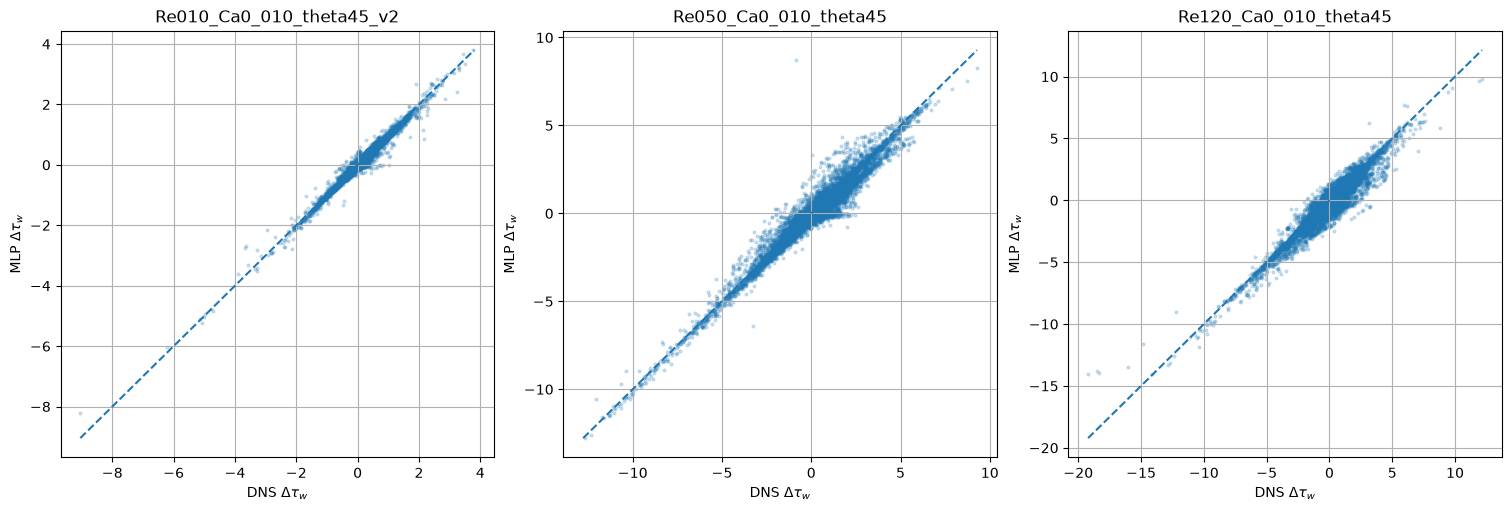

In [49]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

sample_size = 30000
rng = np.random.default_rng(42)

for i, case_name in enumerate(case_names):

    X_case = ml_data[case_name]["test"]["X_scaled"].astype(np.float32)
    Y_true = ml_data[case_name]["test"]["Y"]

    X_tensor = torch.from_numpy(X_case).to(device)

    model.eval()

    with torch.no_grad():
        Y_pred_scaled = model(X_tensor).cpu().numpy().ravel()

    Y_pred = Y_scaler.inverse_transform(Y_pred_scaled.reshape(-1, 1)).ravel()

    if len(Y_true) > sample_size:
        idx = rng.choice(len(Y_true), sample_size, replace=False)
    else:
        idx = np.arange(len(Y_true))

    ax[i].scatter(Y_true[idx], Y_pred[idx], s=4, alpha=0.2)

    lim_min = min(Y_true[idx].min(), Y_pred[idx].min())
    lim_max = max(Y_true[idx].max(), Y_pred[idx].max())

    ax[i].plot([lim_min, lim_max], [lim_min, lim_max], "--")

    ax[i].set_title(case_name)
    ax[i].set_xlabel(r"DNS $\Delta\tau_w$")
    ax[i].set_ylabel(r"MLP $\Delta\tau_w$")
    ax[i].grid(True)

plt.show()

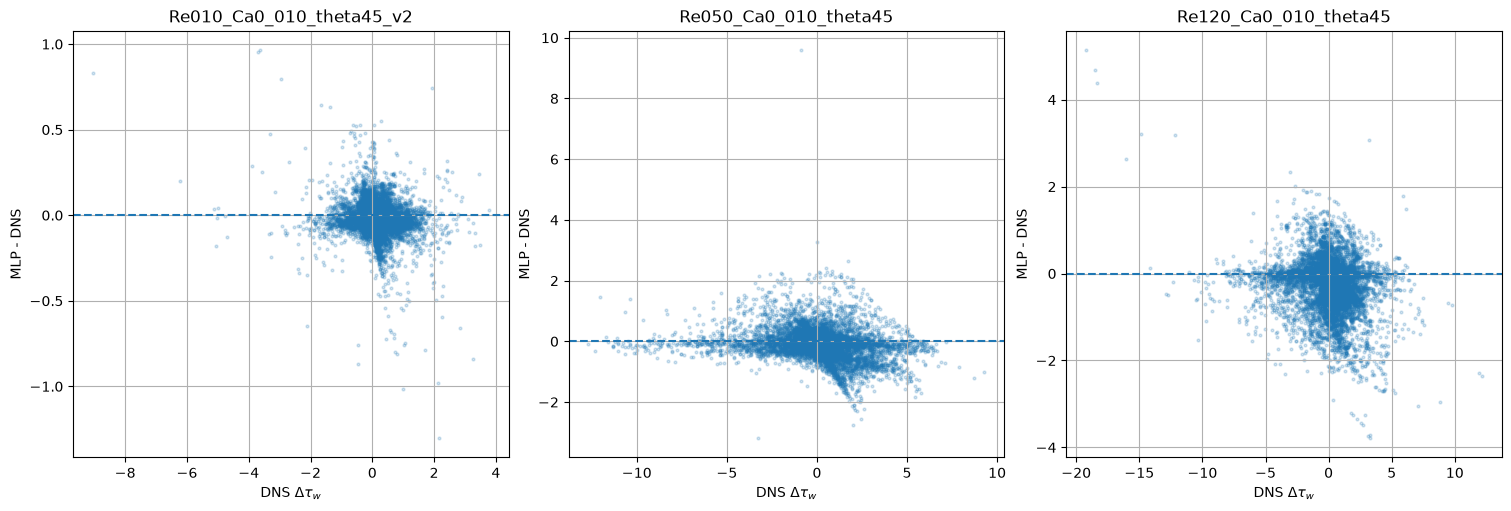

In [50]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

sample_size = 30000
rng = np.random.default_rng(42)

for i, case_name in enumerate(case_names):

    X_case = ml_data[case_name]["test"]["X_scaled"].astype(np.float32)
    Y_true = ml_data[case_name]["test"]["Y"]

    X_tensor = torch.from_numpy(X_case).to(device)

    model.eval()

    with torch.no_grad():
        Y_pred_scaled = model(X_tensor).cpu().numpy().ravel()

    Y_pred = Y_scaler.inverse_transform(Y_pred_scaled.reshape(-1, 1)).ravel()

    residual = Y_pred - Y_true

    if len(Y_true) > sample_size:
        idx = rng.choice(len(Y_true), sample_size, replace=False)
    else:
        idx = np.arange(len(Y_true))

    ax[i].scatter(Y_true[idx], residual[idx], s=4, alpha=0.2)

    ax[i].axhline(0.0, linestyle="--")

    ax[i].set_title(case_name)
    ax[i].set_xlabel(r"DNS $\Delta\tau_w$")
    ax[i].set_ylabel("MLP - DNS")
    ax[i].grid(True)

plt.show()

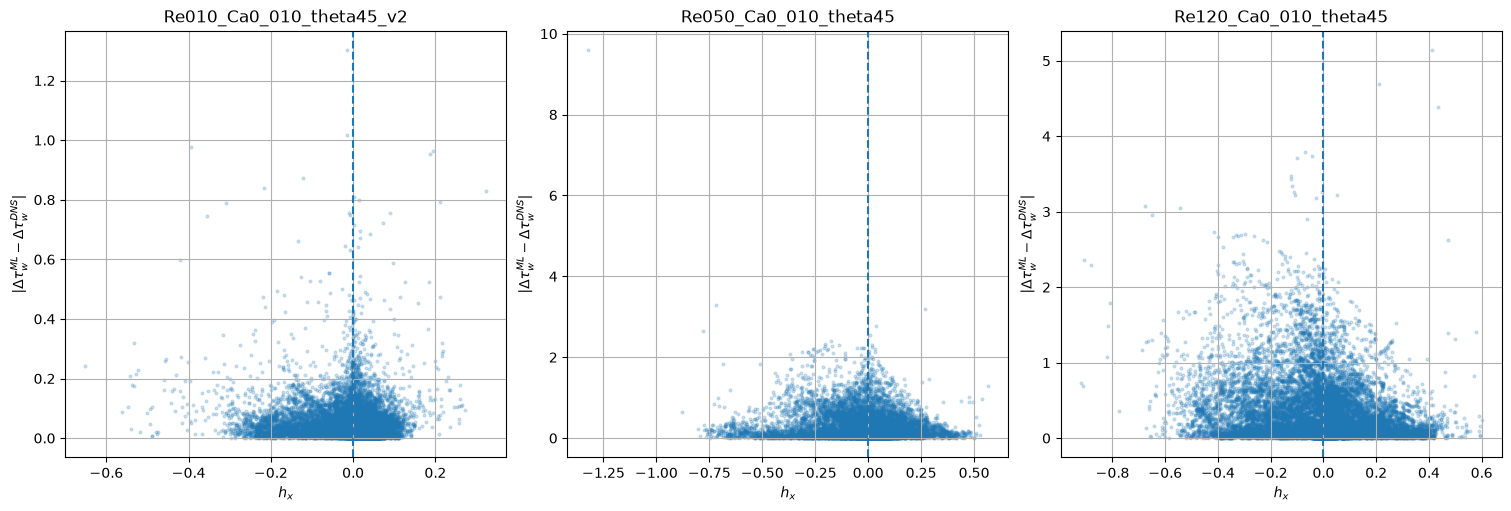

In [51]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

sample_size = 30000
rng = np.random.default_rng(42)

for i, case_name in enumerate(case_names):

    X_scaled = ml_data[case_name]["test"]["X_scaled"].astype(np.float32)
    X_original = ml_data[case_name]["test"]["X"]
    Y_true = ml_data[case_name]["test"]["Y"]

    X_tensor = torch.from_numpy(X_scaled).to(device)

    model.eval()

    with torch.no_grad():
        Y_pred_scaled = model(X_tensor).cpu().numpy().ravel()

    Y_pred = Y_scaler.inverse_transform(Y_pred_scaled.reshape(-1, 1)).ravel()

    h_x = X_original[:, 3]
    error = np.abs(Y_pred - Y_true)

    if len(error) > sample_size:
        idx = rng.choice(len(error), sample_size, replace=False)
    else:
        idx = np.arange(len(error))

    ax[i].scatter(h_x[idx], error[idx], s=4, alpha=0.2)

    ax[i].axvline(0.0, linestyle="--")

    ax[i].set_title(case_name)
    ax[i].set_xlabel(r"$h_x$")
    ax[i].set_ylabel(r"$|\Delta\tau_w^{ML}-\Delta\tau_w^{DNS}|$")
    ax[i].grid(True)

plt.show()